In [ ]:
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = os.path.abspath(
    os.path.join(os.path.dirname(__file__) if "__file__" in dir() else os.getcwd(), "..")
)
sys.path.insert(0, PROJECT_ROOT)
os.chdir(os.path.join(PROJECT_ROOT, "data"))

In [23]:
# show all columns
pd.set_option("display.max_columns", None)

In [12]:
industrial_location_info = pd.read_csv("industrial_location_info.csv")
wiup_indonesia = pd.read_csv("wiup_indonesia.csv")

# Shapefile
industrial_shp = gpd.read_file("industrial_data")

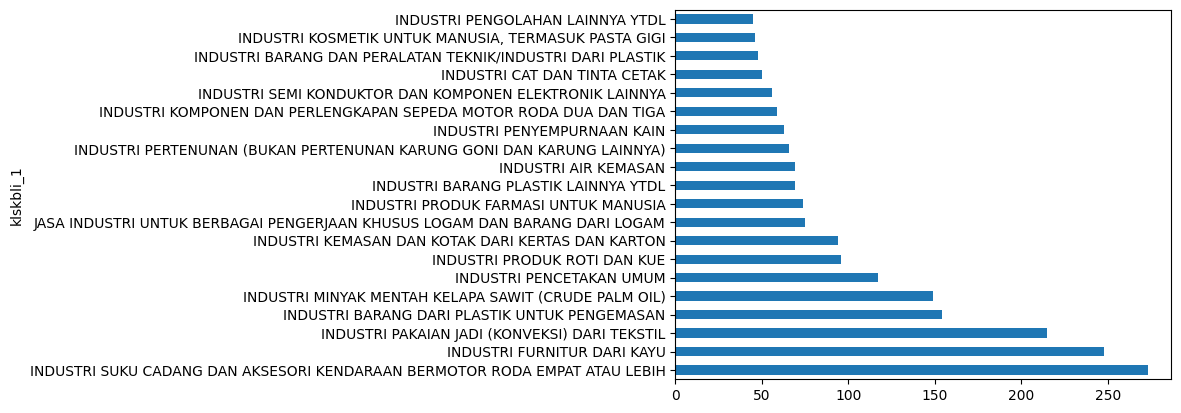

In [19]:
# TO DO:
# is there data on the growth of industries?
# find relative energy consumption per industry
# find relative emissions per industry
# find relative labor per industry
# find relative water consumption per industry

industrial_shp.groupby("klskbli_1").size().reset_index(name="count").sort_values(
    "count", ascending=False
).head(20).plot(kind="barh", x="klskbli_1", y="count", legend=False)
plt.show()

In [ ]:
wiup_indonesia["tgl_berlaku_dt"] = pd.to_datetime(
    wiup_indonesia["tgl_berlaku"], unit="ms", utc=True
)
# (optional) convert to Jakarta time
wiup_indonesia["tgl_berlaku_dt_jkt"] = wiup_indonesia["tgl_berlaku_dt"].dt.tz_convert(
    "Asia/Jakarta"
)
wiup_indonesia["komoditas"] = wiup_indonesia["komoditas"].str.lower()
wiup_indonesia["year"] = wiup_indonesia["tgl_berlaku_dt"].dt.year

In [45]:
# get top 10 commodities per year
wiup_indonesia.groupby(["komoditas"]).size().reset_index(name="count").sort_values(
    "count", ascending=False
).head(10)

,komoditas,count
78,KERIKIL BERPASIR ALAMI (SIRTU),1219
107,PASIR KUARSA,1128
29,BATUBARA,858
0,ANDESIT,685
12,BATU GAMPING,639
134,TANAH URUG,498
18,BATU GUNUNG QUARRY BESAR,453
101,PASIR,410
94,NIKEL,304
13,BATU GAMPING UNTUK INDUSTRI,281


In [55]:
# group by year and komoditas and sum luas_sk
wiup_indonesia.groupby(["komoditas"])["luas_sk"].sum().reset_index().sort_values(
    "luas_sk", ascending=False
).head(10)

,komoditas,luas_sk
28,batubara,4086469.440
87,pasir kuarsa,1421160.248
43,emas,945153.057
76,nikel,856810.780
32,bauksit,710844.660
114,timah,564079.380
44,emas dmp,443104.180
36,bijih besi,360181.730
77,nikel dmp,176829.530
112,tembaga,149829.022


In [60]:
indonesia_yearly_wiup_by_commodity_and_size = (
    wiup_indonesia.groupby(["year", "komoditas"])["luas_sk"]
    .sum()
    .reset_index()
    .sort_values("luas_sk", ascending=False)
)

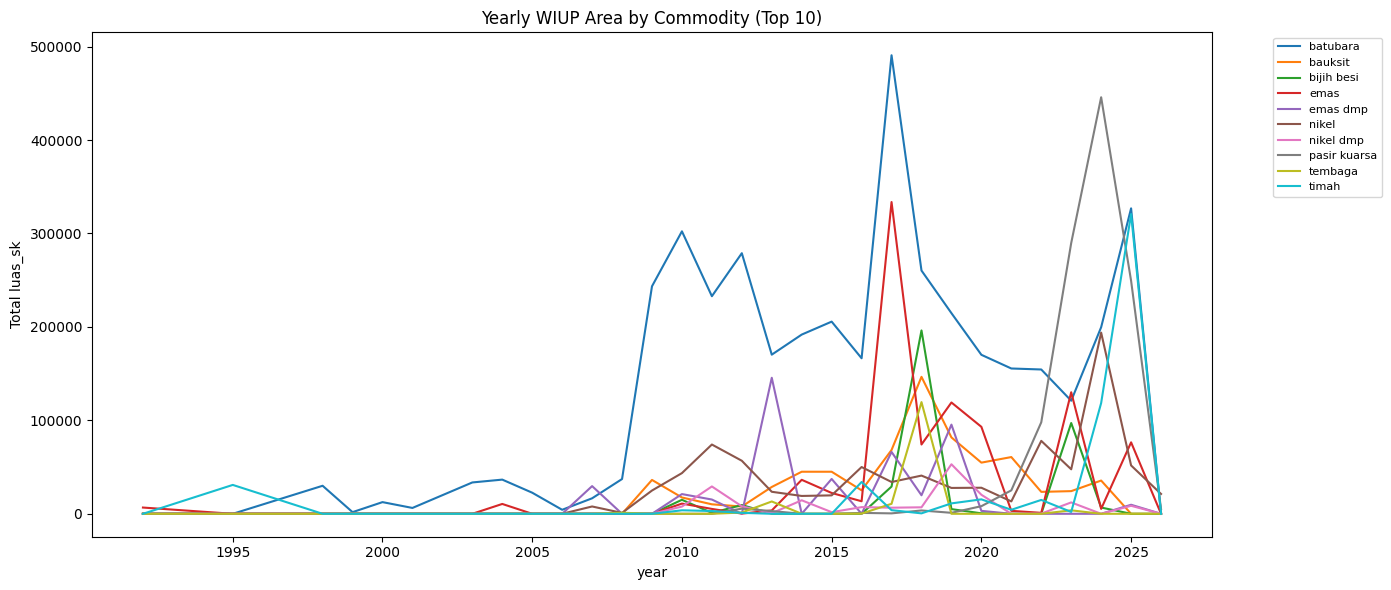

In [68]:
# plot line chart of indonesia_yearly_wiup_by_commodity_and_size. multiple lines for each komoditas
top_commodities = (
    indonesia_yearly_wiup_by_commodity_and_size.groupby("komoditas")["luas_sk"]
    .sum()
    .nlargest(10)
    .index
)
df_top = indonesia_yearly_wiup_by_commodity_and_size[
    indonesia_yearly_wiup_by_commodity_and_size["komoditas"].isin(top_commodities)
]
df_pivot = df_top.pivot(index="year", columns="komoditas", values="luas_sk").fillna(0)

df_pivot.plot(kind="line", figsize=(14, 6))
plt.ylabel("Total luas_sk")
plt.title("Yearly WIUP Area by Commodity (Top 10)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

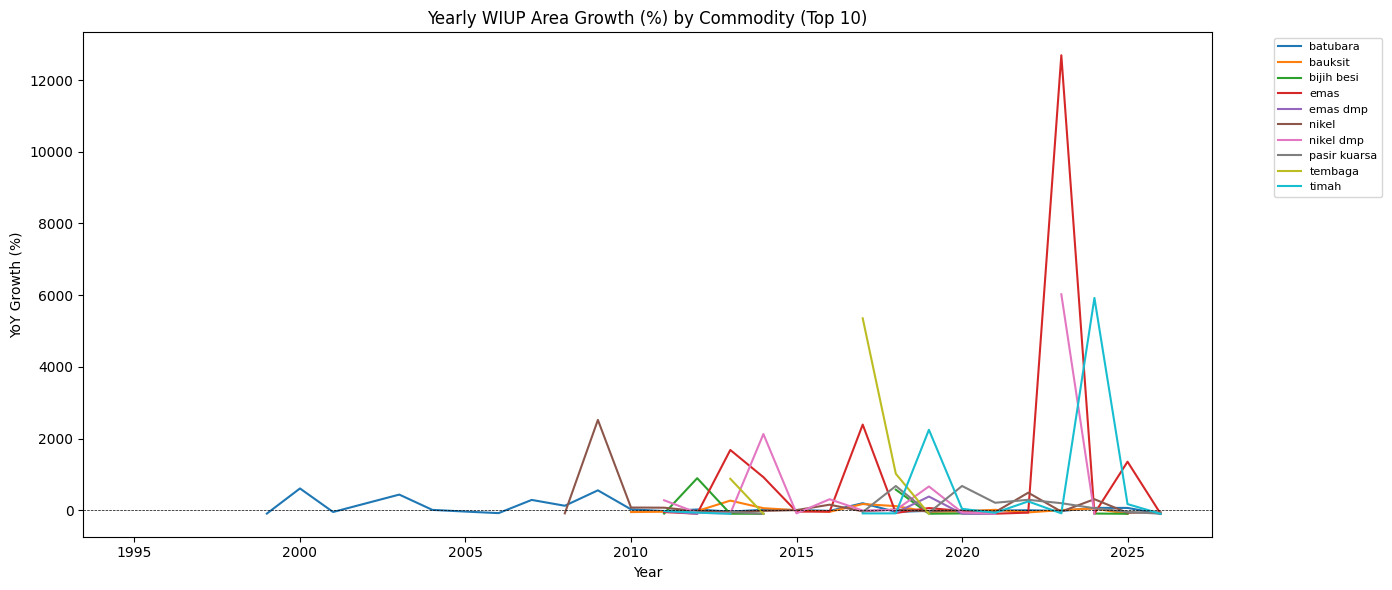

In [69]:
# Plot year-over-year growth (%) in WIUP area by commodity (top 10)
top_commodities = (
    indonesia_yearly_wiup_by_commodity_and_size.groupby("komoditas")["luas_sk"]
    .sum()
    .nlargest(10)
    .index
)
df_top = indonesia_yearly_wiup_by_commodity_and_size[
    indonesia_yearly_wiup_by_commodity_and_size["komoditas"].isin(top_commodities)
]
df_pivot = df_top.pivot(index="year", columns="komoditas", values="luas_sk").fillna(0)

# Calculate year-over-year percentage growth
df_growth = df_pivot.pct_change() * 100

df_growth.plot(kind="line", figsize=(14, 6))
plt.ylabel("YoY Growth (%)")
plt.xlabel("Year")
plt.title("Yearly WIUP Area Growth (%) by Commodity (Top 10)")
plt.axhline(y=0, color="black", linewidth=0.5, linestyle="--")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [70]:
df_growth

komoditas,batubara,bauksit,bijih besi,emas,emas dmp,nikel,nikel dmp,pasir kuarsa,tembaga,timah
year,,,,,,,,,,
1992.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995.0,NaN,NaN,NaN,-1.000000e+02,NaN,NaN,NaN,NaN,NaN,inf
1998.0,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-100.000000
1999.0,-94.108429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000.0,607.130730,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001.0,-49.891957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003.0,435.793004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004.0,9.044297,NaN,NaN,inf,NaN,NaN,NaN,NaN,NaN,NaN
2005.0,-38.290432,NaN,NaN,-1.000000e+02,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
indonesia_yearly_wiup_by_commodity_and_size.year.value_counts()

year
2023.0    53
2024.0    50
2025.0    46
2020.0    39
2021.0    35
2022.0    35
2018.0    30
2017.0    28
2019.0    22
2011.0    20
2026.0    19
2014.0    17
2016.0    17
2012.0    17
2010.0    17
2013.0    16
2015.0    11
2009.0     9
2007.0     5
2008.0     3
2006.0     2
2003.0     2
2004.0     2
1998.0     1
2005.0     1
1995.0     1
2000.0     1
1992.0     1
2001.0     1
1999.0     1
2028.0     1
Name: count, dtype: int64

In [73]:
last_5

komoditas,andesit,antimon dmp,antimoni,arsen,aspal,ball clay,barit,basalt,batu andesit,batu apung,batu besi,batu gamping,batu gamping untuk industri,batu gamping untuk semen,batu garnet,batu gunung quarry besar,batu kali,batu kapur,batu kapur untuk semen,batu kapur/ gamping,batu kuarsa,batu lempung,batu lempung (tanah liat),batuan,batuan (trass),batuan aspal,batubara,batugamping,batugamping untuk semen,batupasir,bauksit,bauksit dmp,bentonit,besi,bijih besi,bijih besi dmp,bijih nikel,bijih timah,clay,diorit,dolomit,emas,emas dmp,"emas,tembaga,lds",feldspar,fire clay,fosfat,gabro,galena,galena dmp,gamping,gamping untuk semen,grafit,granit,granodiorit,hematite,intan alluvial,kalsedon,kalsit,kaolin,kerikil berpasir alami (sirtu),kerikil galian dari bukit,kerikil sungai,kromit,kuarsit,mangaan,mangan,marmer,mineral bukan logam,molibdenum,nickel,nikel,nikel dmp,obsidian,onik,pasir,pasir bangunan,pasir besi,pasir besi dmp,pasir kuarsa,pasir laut,pasir pasang,pasir timah,pasir urug,"pasir, batu, kerikil",peridotit,perlit,pirofilit,pumice,rijang,"seng, timah hitam dmp",sirtu,slate,tanah diatome,tanah liat,tanah liat,tanah merah (laterit),tanah urug,tembaga,tembaga dmp,timah,timah dmp,timah hitam,timbal,timbal dan seng,trakhit,tras,trass,zeolit,zirkon
year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023.0,29087.91,0.0,0.0,8.59,0.0,0.0,0.0,272.46,0.0,4.35,0.0,16092.87,29350.90,0.0,0.0,7603.11,120.25,0.0,0.0,0.0,2620.53,0.0,0.0,242.08,0.0,0.0,121002.280,0.0,0.0,0.0,24253.0,0.0,907.07,587.2,97144.0,0.0,0.0,0.0,2031.95,27.88,124.17,130079.16,0.0,0.0,322.62,5.0,0.00,58.64,1867.7,0.0,0.0,0.0,35.56,2379.10,76.41,0.0,0.0,0.0,4352.96,932.34,6839.12,7.24,0.00,0.0,1863.19,0.0,10.0,327.34,0.0,0.0,0.0,47619.12,12185.0,20.0,0.00,3898.47,0.0,0.0,0.0,289796.44,4842.52,393.05,0.0,188.47,0.0,270.67,20.0,29.82,0.0,107.2,0.0,0.0,0.00,0.0,897.84,0.0,2157.04,1854.27,3714.0,0.0,1968.80,0.0,0.0,0.0,0.0,0.0,360.07,0.0,28.68,2325.30
2024.0,7896.16,0.0,0.0,0.00,0.0,145.5,0.0,126.50,0.0,5.68,0.0,11175.06,33033.08,0.0,0.0,10990.40,157.24,0.0,0.0,0.0,634.19,0.0,0.0,120.80,0.0,0.0,199672.890,0.0,0.0,0.0,35575.0,0.0,757.49,1168.0,6707.0,0.0,0.0,0.0,1193.97,96.65,113.04,5263.80,0.0,0.0,89.48,0.0,175.53,0.00,0.0,0.0,0.0,0.0,189.13,1023.06,33.02,0.0,0.0,10.0,0.00,2410.67,5945.79,3.21,2.91,0.0,501.65,0.0,0.0,383.20,5000.0,0.0,0.0,193883.21,0.0,59.2,49.34,2345.76,0.0,0.0,0.0,445791.65,0.00,16114.77,0.0,218.15,0.0,1790.66,0.0,88.16,0.0,0.0,0.0,0.0,7.18,0.0,153.50,0.0,1146.72,18111.00,0.0,0.0,118541.43,0.0,0.0,0.0,0.0,7.6,263.52,0.0,32.43,2149.72
2025.0,3628.71,0.0,0.0,0.00,0.0,1713.0,0.0,997.85,0.0,5.29,0.0,5422.02,8862.18,0.0,0.0,3801.23,60.00,0.0,0.0,0.0,35.74,0.0,0.0,0.00,0.0,0.0,326909.602,0.0,0.0,0.0,0.0,0.0,792.21,500.0,0.0,0.0,0.0,0.0,1106.14,651.99,161.49,76478.00,9670.0,0.0,136.64,0.0,0.00,0.00,0.0,0.0,0.0,0.0,474.70,614.73,86.05,0.0,0.0,0.0,108.60,1741.44,2828.99,0.00,10.63,0.0,518.70,0.0,0.0,1000.96,0.0,0.0,0.0,51741.35,8565.0,70.0,0.00,2837.29,0.0,0.0,0.0,249364.50,981.56,1582.76,0.0,24.76,0.0,733.54,70.0,5.73,3.0,0.0,0.0,0.0,0.00,723.0,282.19,0.0,0.00,6166.61,0.0,0.0,320766.74,0.0,0.0,0.0,0.0,0.0,180.55,0.0,48.49,4897.41
2026.0,170.69,0.0,0.0,0.00,0.0,0.0,0.0,0.75,0.0,0.00,0.0,1267.84,45.08,0.0,0.0,79.96,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,5.80,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,29.14,0.00,0.0,0.0,0.0,0.00,86.46,168.20,0.00,0.00,0.0,95.10,0.0,0.0,16.13,0.0,0.0,0.0,21240.00,0.0,0.0,0.00,128.47,0.0,0.0,0.0,5134.35,0.00,139.83,0.0,0.00,0.0,0.00,0.0,91.34,0.0,0.0,0.0,0.0,0.00,0.0,241.54,0.0,0.00,49.40,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,11.00,0.0,0.00,0.00
2028.0,4.63,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,

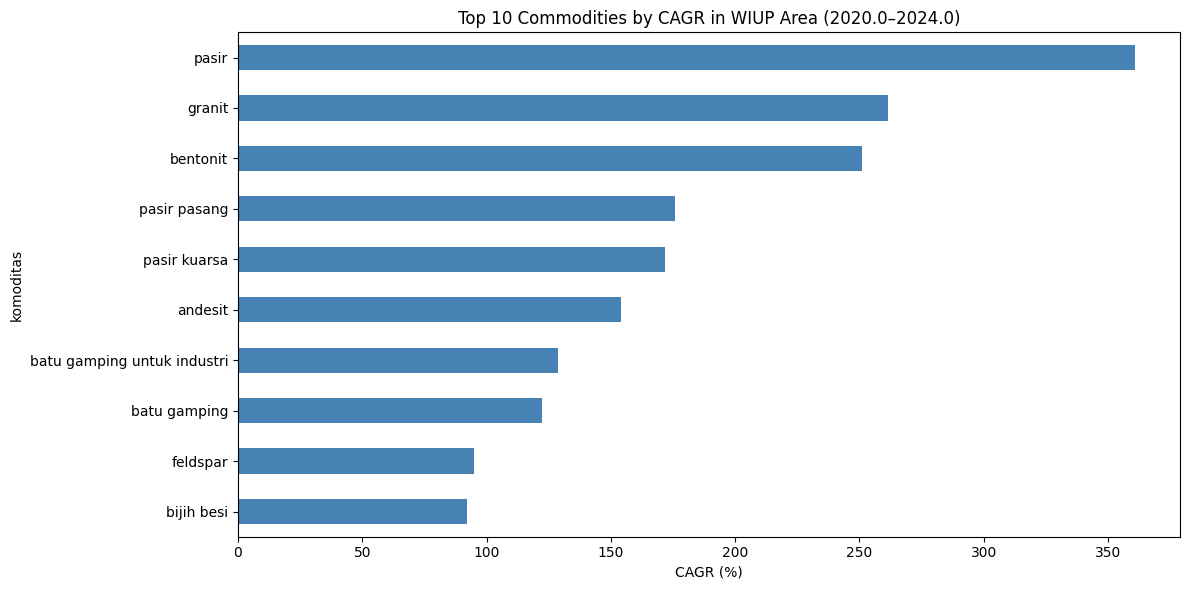

                               CAGR (%)
komoditas                              
pasir                        360.861106
granit                       261.357825
bentonit                     250.834040
pasir pasang                 175.949737
pasir kuarsa                 171.952745
andesit                      154.236870
batu gamping untuk industri  128.908456
batu gamping                 122.433345
feldspar                      94.909753
bijih besi                    92.062409


In [74]:
# CAGR over last 5 years by commodity (excluding 2025)
import numpy as np

df_all = indonesia_yearly_wiup_by_commodity_and_size.pivot(
    index="year", columns="komoditas", values="luas_sk"
).fillna(0)
df_all = df_all.sort_index()
df_all = df_all[df_all.index < 2025]

# Last 5 years in the data
last_5 = df_all.tail(5)
n_years = last_5.index[-1] - last_5.index[0]

# CAGR = (end / start)^(1/n) - 1, only where start > 0
start = last_5.iloc[0]
end = last_5.iloc[-1]
cagr = ((end / start) ** (1 / n_years) - 1) * 100
cagr = cagr.replace([np.inf, -np.inf], np.nan).dropna()

# Top 10 by highest CAGR
top_cagr = cagr.nlargest(10)

top_cagr.sort_values().plot(kind="barh", figsize=(12, 6), color="steelblue")
plt.xlabel("CAGR (%)")
plt.title(f"Top 10 Commodities by CAGR in WIUP Area ({last_5.index[0]}–{last_5.index[-1]})")
plt.tight_layout()
plt.show()

print(top_cagr.sort_values(ascending=False).to_frame("CAGR (%)"))